<a href="https://colab.research.google.com/github/Mohameddfxxcxx/Car-Price-Predict-/blob/main/Apple_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'apple-quality:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F4291772%2F7384155%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240830%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240830T234443Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D43d6df331672f6df4d6f95026af6f9c630f654c0c7c3e3765e87f3de1cb7fde992a61dbf371ee48ad2159b56a865a965cbfe31adadd43433eeae9bd97e56a2caf6000bd372b5c7b1f0b5ff310add16717a8db992a064a5c3aa7ce62c1a6f11d4c096ed652c63538f3490df93e4b987cd31009139f0d2afd3279df01e091efd72d27d5af88155ecd33bb47d4fd0d85812fd28681f4ac91755291da92a4f80c3880907b161077c537da8b21cc380a527e5e6d7beee9c064e7dc65706b0d773d4c65d76881cb07cefe602a5c1af971a467fd97cc51c551be925b277518e4b574afe33bcfc99b11858436f8820c2dd2ebdc8279f3c653dac8b7c530b3fae9635c2c1'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 174361 bytes downloaded
Downloaded and uncompressed: apple-quality
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/apple-quality/apple_quality.csv


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import statsmodels
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay

In [4]:
apple_df = pd.read_csv('/kaggle/input/apple-quality/apple_quality.csv')
apple_df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [5]:
apple_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


In [6]:
# Removing insignificant variables
apple_df.drop( 'A_id', axis = 1, inplace=True)

In [7]:
# Convert 'Acidity' column from object type to float64
apple_df['Acidity'] = pd.to_numeric(apple_df['Acidity'], errors='coerce')

In [8]:
apple_df.columns

Index(['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness',
       'Acidity', 'Quality'],
      dtype='object')

In [9]:
apple_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Size,4000.0,-0.503015,1.928059,-7.151703,-1.816765,-0.513703,0.805526,6.406367
Weight,4000.0,-0.989547,1.602507,-7.149848,-2.011770,-0.984736,0.030976,5.790714
Sweetness,4000.0,-0.470479,1.943441,-6.894485,-1.738425,-0.504758,0.801922,6.374916
Crunchiness,4000.0,0.985478,1.402757,-6.055058,0.062764,0.998249,1.894234,7.619852
Juiciness,4000.0,0.512118,1.930286,-5.961897,-0.801286,0.534219,1.835976,7.364403
Ripeness,4000.0,0.498277,1.874427,-5.864599,-0.771677,0.503445,1.766212,7.237837
Acidity,4000.0,0.076877,2.110270,-7.010538,-1.377424,0.022609,1.510493,7.404736


In [10]:
# checking for null values
null = pd.DataFrame({'Null Values' : apple_df.isna().sum(), 'Percentage Null Values' : (apple_df.isna().sum()) /len(apple_df) * (100)})
null

,Null Values,Percentage Null Values
Size,1,0.024994
Weight,1,0.024994
Sweetness,1,0.024994
Crunchiness,1,0.024994
Juiciness,1,0.024994
Ripeness,1,0.024994
Acidity,1,0.024994
Quality,1,0.024994


from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Null Values']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Null Values'}, axis=1)
              .sort_values('Null Values', ascending=True))
  xs = counted['Null Values']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = null.sort_values('Null Values', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Null Values')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Percentage Null Values']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Percentage Null Values'}, axis=1)
              .sort_values('Percentage Null Values', ascending=True))
  xs = counted['Percentage Null Values']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = null.sort_values('Percentage Null Values', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Percentage Null Values')
_ = plt.ylabel('count()')

In [12]:
apple_df.dropna(inplace=True)

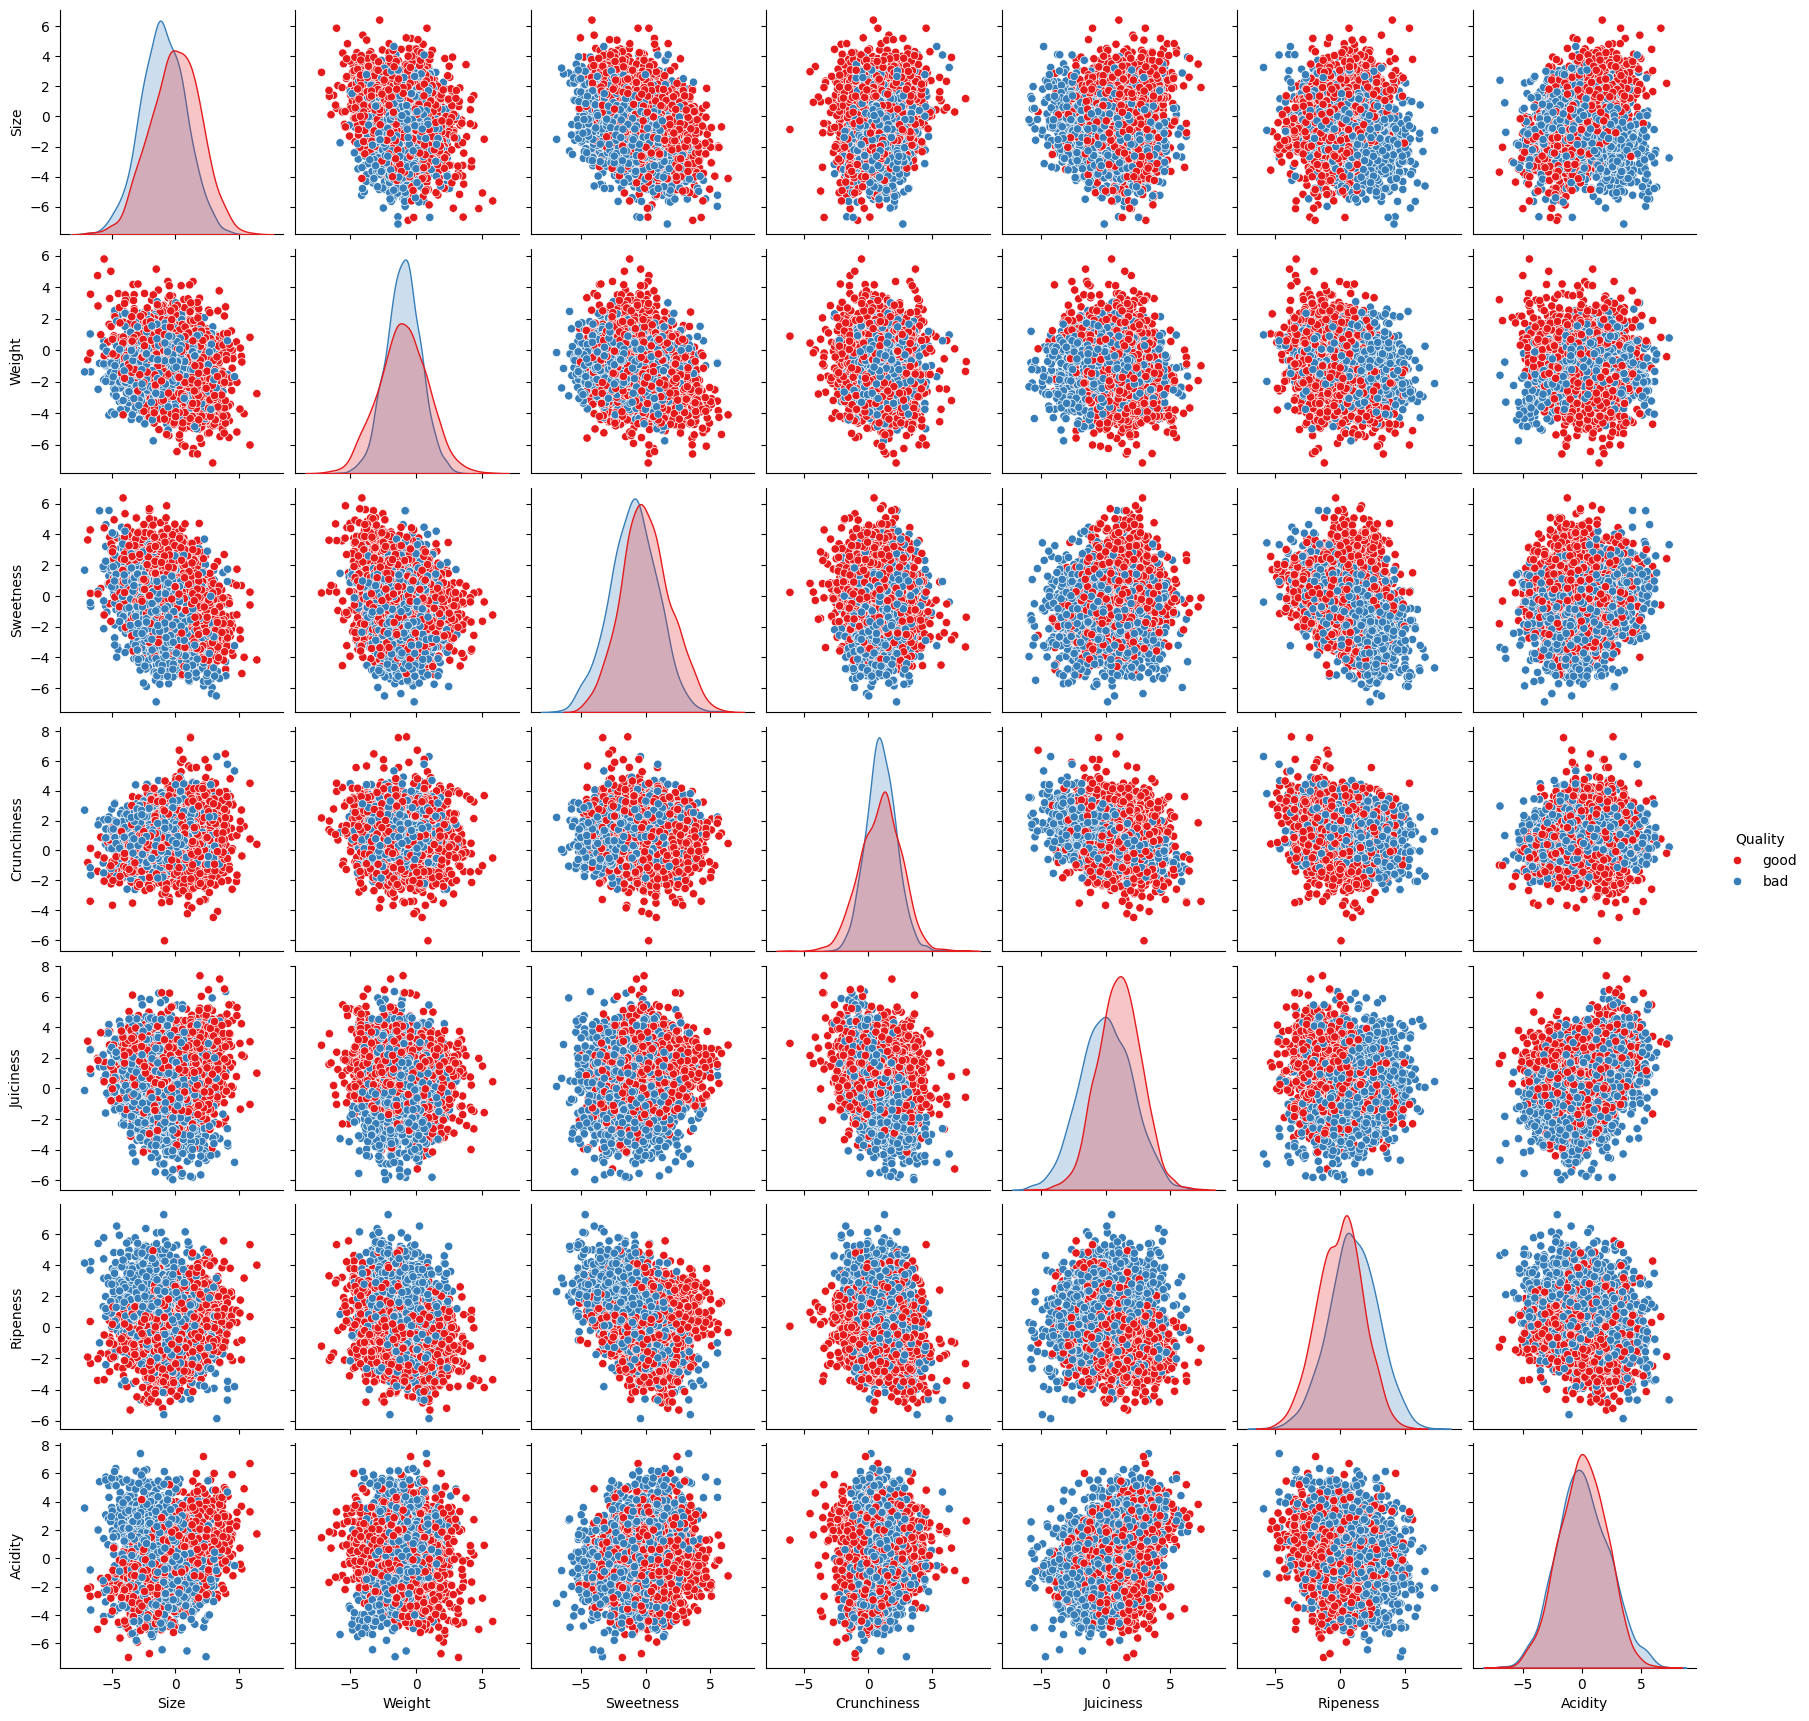

In [13]:
sns.pairplot(apple_df,hue='Quality',palette='Set1')

In [14]:
apple_df['Quality'].value_counts()

,count
Quality,
good,2004
bad,1996


In [15]:
apple_df['Quality'] = apple_df['Quality'].replace({'good': 1, 'bad': 0}).astype(int)

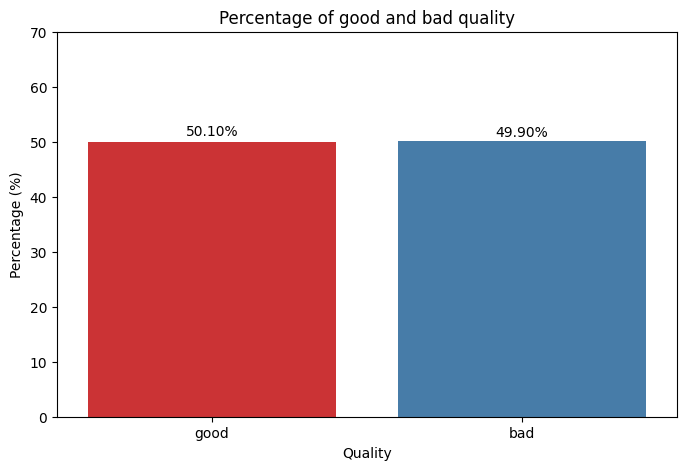

In [16]:
# Calculating the percentage of each class
percentage = apple_df['Quality'].value_counts(normalize=True) * 100

# Plotting the percentage of each class
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=percentage.index, y=percentage, palette='Set1')
plt.title('Percentage of good and bad quality')
plt.xlabel('Quality')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['good', 'bad'])
plt.yticks(ticks=range(0,80,10))

# Displaying the percentage on the bars
for i, p in enumerate(percentage):
    ax.text(i, p + 0.5, f'{p:.2f}%', ha='center', va='bottom')

plt.show()

In [17]:
X = apple_df.iloc[:,:-1]

In [18]:
y = apple_df.iloc[:,-1]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

# print dimension of train set
print('X_train', X_train.shape)
print('y_train', y_train.shape)

# print dimension of test set
print('X_test', X_test.shape)
print('y_test', y_test.shape)

X_train (3200, 7)
y_train (3200,)
X_test (800, 7)
y_test (800,)


In [20]:
from sklearn.feature_selection import RFECV
model = LogisticRegression()

selector = RFECV(
    estimator=model,
    min_features_to_select=3,
    scoring='f1',
    cv=5,
)

In [21]:
selector.fit(X_train,y_train)

RFECV(cv=5, estimator=LogisticRegression(), min_features_to_select=3,
      scoring='f1')

In [22]:
X_train.columns[selector.support_]

Index(['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness',
       'Acidity'],
      dtype='object')

In [23]:
len(X_train.columns[selector.support_])

7

In [24]:
X_train = X_train.loc[:,selector.support_]
X_train.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
1420,-1.304400,-5.032275,0.291006,3.394300,0.030702,-3.116206,-0.185962
1638,-1.423864,0.329041,-1.132315,1.596105,1.275958,0.269907,-0.235372
616,1.701191,-0.242767,-1.610199,2.587950,-1.843153,-0.286345,1.402366
184,-4.968508,-0.814306,-0.481643,1.814280,1.347889,3.772847,1.951706
2075,-2.295814,-2.917693,-1.058796,0.617372,-1.959403,2.531234,-3.004119


In [25]:
from sklearn.model_selection import GridSearchCV


parameters = {'class_weight': [None, 'balanced'], 'solver':['newton-cg', 'lbfgs', 'liblinear','sag','saga']}

model = LogisticRegression(fit_intercept = True, max_iter = 1000)

grid_search = GridSearchCV(model, parameters, cv = 5, scoring = 'f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'class_weight': [None, 'balanced'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='f1')

In [26]:
pd.DataFrame((grid_search.cv_results_)).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.025570,0.008125,0.007467,0.002942,None,newton-cg,"{'class_weight': None, 'solver': 'newton-cg'}",0.764253,0.767584,0.7375,0.747287,0.769912,0.757307,0.012692,1
1,0.010425,0.000336,0.005856,0.000123,None,lbfgs,"{'class_weight': None, 'solver': 'lbfgs'}",0.764253,0.767584,0.7375,0.747287,0.769912,0.757307,0.012692,1
3,0.015854,0.004104,0.004387,0.000431,None,sag,"{'class_weight': None, 'solver': 'sag'}",0.764253,0.767584,0.7375,0.747287,0.769912,0.757307,0.012692,1
4,0.011643,0.001241,0.004271,0.000227,None,saga,"{'class_weight': None, 'solver': 'saga'}",0.764253,0.767584,0.7375,0.747287,0.769912,0.757307,0.012692,1
2,0.011140,0.004697,0.006681,0.001878,None,liblinear,"{'class_weight': None, 'solver': 'liblinear'}",0.762346,0.767584,0.7375,0.748447,0.769912,0.757158,0.012334,5


In [27]:
best_model = grid_search.best_estimator_
best_model

LogisticRegression(max_iter=1000, solver='newton-cg')

In [28]:
best_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='newton-cg')

<Axes: xlabel='Feature'>

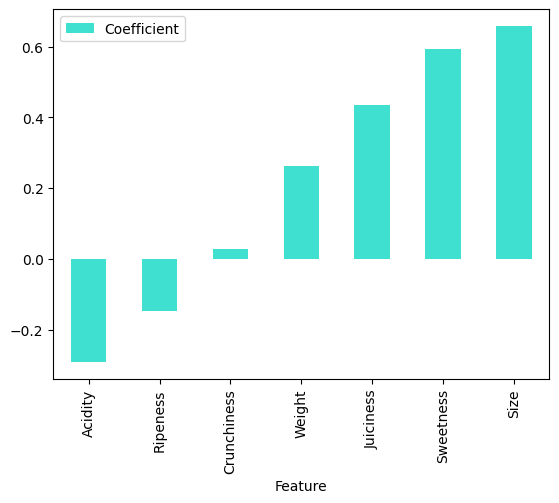

In [30]:
# Feature Importance
feature_importance_df = pd.DataFrame({"Feature": list(X_train.columns), "Coefficient": best_model.coef_[0]})
feature_importance_df.sort_values("Coefficient").plot.bar(x = 'Feature', y='Coefficient',color='Turquoise')

In [31]:
feature_importance_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
0,Size,0.657694
2,Sweetness,0.594048
4,Juiciness,0.434200
1,Weight,0.262524
3,Crunchiness,0.028123
5,Ripeness,-0.147369
6,Acidity,-0.291278


In [32]:
X_test = X_test.loc[:,selector.support_]
X_test.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
1203,-1.328021,-3.509870,1.180195,1.844719,-2.361462,-0.453976,-3.130528
2827,0.553790,-0.114322,-1.075704,-0.096240,1.380802,-1.297286,-0.037817
2325,-1.447189,-1.675930,-0.464820,2.638307,-2.620991,3.498612,-0.495154
3916,-0.369054,2.500206,-1.124518,-0.332943,-0.710734,-0.782862,0.473000
3821,3.024898,-1.870915,-2.666318,2.286341,-3.604327,0.735995,-0.059953


In [33]:
def metrics_calculator(clf, X_test, y_test, model_name):
    """
    This function calculates various performance metrics for a given classifier model on test data.
    The metrics are calculated specifically for class 1.
    """
    # Calculate predictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Compute performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_proba)

    # Create a DataFrame to store the results
    result = pd.DataFrame({
        model_name: [
            f"{accuracy * 100:.2f}%",
            f"{precision * 100:.2f}%",
            f"{recall * 100:.2f}%",
            f"{f1 * 100:.2f}%",
            f"{auc * 100:.2f}%"
        ]
    }, index=['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-score (Class 1)', 'AUC (Class 1)'])

    return result

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from matplotlib.colors import LinearSegmentedColormap

def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):
    """
    This function provides a comprehensive report of the model's performance, including:
    - Classification reports for both training and test sets
    - Confusion matrix for the test set
    - ROC curve for the test set
    """

    # Set the font scale for seaborn plots
    sns.set(font_scale=1.2)

    # Classification report for the training set
    y_pred_train = clf.predict(X_train)
    print("\n\t  Classification report for training set")
    print("-" * 55)
    print(classification_report(y_train, y_pred_train))

    # Classification report for the test set
    y_pred_test = clf.predict(X_test)
    print("\n\t  Classification report for test set")
    print("-" * 55)
    print(classification_report(y_test, y_pred_test))

    # Create figure and subplots
    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, figsize=(15, 5), dpi=100, gridspec_kw={'width_ratios': [2, 2, 1]}
    )

    # Define a colormap resembling an apple (red theme)
    apple_red = LinearSegmentedColormap.from_list('apple_red', [(0, '#FF0000'), (1, '#FFFFFF')])
    apple_red_r = apple_red.reversed()

    # Plot confusion matrix for test set
    ConfusionMatrixDisplay.from_estimator(
        clf, X_test, y_test, colorbar=False, cmap=apple_red_r, ax=ax1
    )
    ax1.set_title('Confusion Matrix for Test Data')
    ax1.grid(False)

    # Plot ROC curve for test set
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve for Test Data (Positive label: 1)')

    # Report results for the specified class
    result = metrics_calculator(clf, X_test, y_test, model_name)
    table = ax3.table(
        cellText=result.values,
        colLabels=result.columns,
        rowLabels=result.index,
        loc='center'
    )
    table.scale(0.6, 2)
    table.set_fontsize(12)
    ax3.axis('tight')
    ax3.axis('off')

    # Modify color for the header row in the table
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_color('#FF0000')

    plt.tight_layout()
    plt.show()


	  Classification report for training set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1592
           1       0.75      0.77      0.76      1608

    accuracy                           0.75      3200
   macro avg       0.75      0.75      0.75      3200
weighted avg       0.75      0.75      0.75      3200


	  Classification report for test set
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.72      0.73       404
           1       0.72      0.76      0.74       396

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800



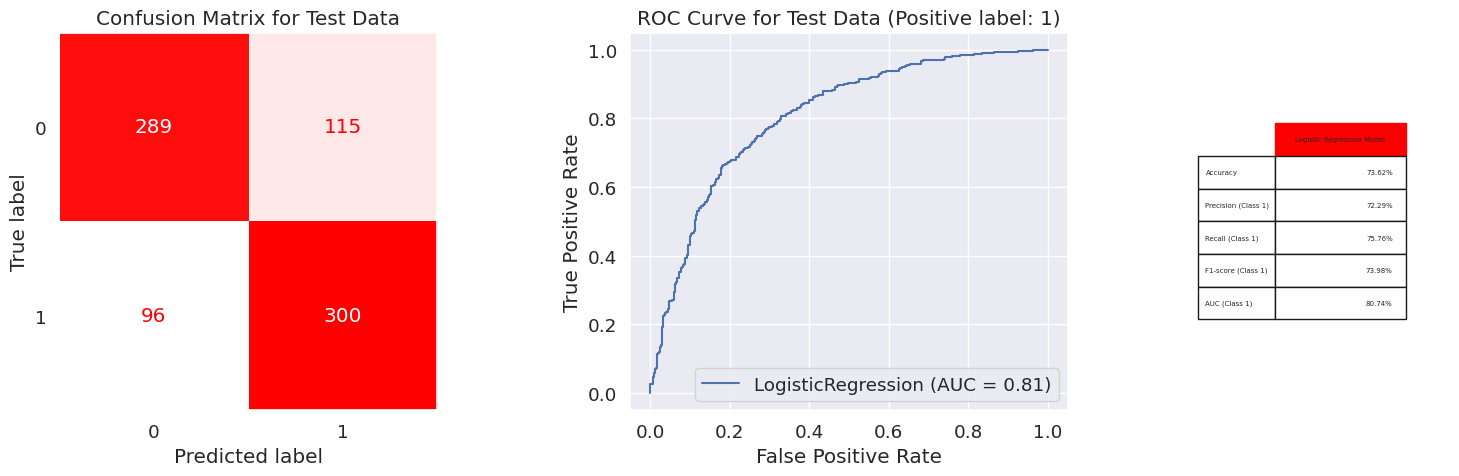

In [35]:
model_evaluation(best_model, X_train, X_test, y_train, y_test, 'Logistic Regression Model')